# How often does the FFT day-of-year climatology get zeroed out?

This notebook was generated by Claude.

`downscaling_bias_artifacts_explainer.ipynb` traced a specific bias-artifact mechanism back to
`calculate_doy_means(..., clim_method="fft", allow_negative_values=False)`
(`saidownscale.downscaling_utils`): fitting only the mean + 3 harmonics to a bimodal or otherwise
sharply-shaped seasonal cycle can make the fit undershoot below zero in the trough, and
`allow_negative_values=False` -- which every variable's production downscaling call uses
unconditionally (`DownscalingPipeline._apply_spatial_downscaling`) -- then floors that undershoot to a
hard `0`. Two consequences follow directly: the flat `0` collapses the final downscaled value on
that calendar day to exactly zero regardless of what the debiased model actually simulated
(multiplicative path), or adds a slightly-too-high climatology term (additive path); and, for the
multiplicative variables, the days immediately flanking the flat `0` divide by a near-zero
denominator and blow up before being clipped at `max_residual=100`.

This notebook doesn't look at any of that downstream machinery. It asks the narrower, cheaper
question underneath it: **for each variable, on how many (day-of-year, pixel) combinations does the
FFT fit actually go negative in the first place** -- i.e. how often would the floor even trigger --
using only the ERA5 observational climatology the fit is built from. Because this depends only on
`obs_fine` and not on any particular GCM, scenario, or ensemble member, it's one computation per
variable rather than the every-`(scenario, variable, member)`-leaf multiplication that makes
`plausible-value-check.ipynb` expensive. It's still not cheap, though: computing the day-of-year
mean is a full reduction over the entire multi-decade daily global fine-resolution ERA5 record, once
per variable -- comparable to that same notebook's `obs_doy_bounds` step, which its own docs call
"the expensive part."

For every variable we report three things: **how often** the fit would go negative (fraction of the
`(dayofyear, lat, lon)` domain), **where and when** (a spatial map of how much of the year each
pixel is affected, and a day-of-year curve of how much of the map is affected on each day), and
**how much** it distorts the long-term mean of the climatology at each pixel. That last quantity is
exactly `clipped.mean("dayofyear") - unclipped.mean("dayofyear")`, which is provably `>= 0`:
flooring a negative excursion up to zero without a compensating adjustment elsewhere can only raise
the day-of-year-averaged mean, never lower it.

**Not executed here** -- needs cluster + S3/catalog access to ERA5. Run this on a cluster, then fill
in the Summary section at the end with what actually came back.

In [3]:
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import coiled
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from dask_array.xarray import register

from saidownscale.config import ClusterConfig
from saidownscale.downscaling_utils import fft_smooth_nharmonics, get_obs, subset_space

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters --------------------------------------------------------
OBS_DATASET = "ERA5"
# Matches DownscalingConfig's default train period (src/saidownscale/downscaling_config.py) -- the same window
# calculate_doy_means is actually built from in production.
OBS_START_YEAR = 1978
OBS_END_YEAR = 2014

# Every variable's downscaling call uses allow_negative_values=False (tas, tasmax, tasmin, pr,
# rsds, dtr, hurs); we discover which of these ERA5 actually stores and skip the rest below,
# rather than assuming.
CANDIDATE_VARIABLES = ["pr", "rsds", "hurs"]  # "tasmin",

# Optional fast path for a quick regional test before committing to a global run: set to
# (lat_min, lat_max, lon_min, lon_max), or None to check the whole globe.
SUBSET_BOUNDS = None
# SUBSET_BOUNDS = (-5, 16, 33, 55)  # Southern Africa / Horn of Africa -- same box the bias explainer used

## Compute

Reading the full multi-decade daily global ERA5 record and reducing it to a day-of-year mean is a
real distributed job, so we run it on a [Coiled](https://coiled.io) cluster, mirroring
`saidownscale.config.ClusterConfig`. Unlike `plausible-value-check.ipynb`, this notebook does one such
reduction per **variable** rather than per `(scenario, variable, member)` leaf, so a smaller pool is
plenty -- the FFT smoothing itself, once the day-of-year mean is in hand, runs in memory on the
driver (see the note below) and needs no cluster at all.

In [2]:
cfg = ClusterConfig(n_workers=15)
cluster = coiled.Cluster(
    name="srm-qaqc-fft-clipping-check",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
    worker_disk_size=200,
)
client = hijack(cluster.get_client())
client

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_pr  │ Source wheel built from                                 │
│                    │ /scratch/synced/notebooks/QA_QC/pr                      │
│   coiled_local_src │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/coiled_local_src/coi   │
│                    │ led_local_src-0.0.0-py3-none-any.whl                    │
│   srm              │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/srm/srm-0.12.0.post3   │
│                    │ +g53973964e.d20260729-py3-none-any.whl                  │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

<frisky.Client: scheduler="wss://cluster-kvrpu.dask.host/9sXW6bxZojw7Yk4v/frisky-comm?__frisky_dial_host=100.23.161.228" id="client-0">

## Discover which variables ERA5 actually has

Same "discover, don't hand-maintain a list" convention as the other QA notebooks: try each
candidate against the catalog and skip (with a clear message) whichever ones aren't there, instead
of assuming.

In [4]:
def discover_variables(candidates: list[str]) -> list[str]:
    """Variables from `candidates` that ERA5 actually stores; skip (don't fabricate) the rest."""
    available = []
    for var in candidates:
        try:
            get_obs(var=var, dataset_name=OBS_DATASET)
            available.append(var)
        except Exception as exc:
            print(f"  skipping {var!r}: not available from {OBS_DATASET} ({type(exc).__name__})")
    return available


VARIABLES = discover_variables(CANDIDATE_VARIABLES)
print(f"Checking {len(VARIABLES)} variable(s): {VARIABLES}")

Checking 3 variable(s): ['pr', 'rsds', 'hurs']


## The day-of-year climatology, three ways

For a given variable, `calculate_doy_means` computes `obs_fine.groupby("time.dayofyear").mean("time")`
-- the expensive full-record reduction -- and then, for `clim_method="fft"`, feeds that result
through `fft_smooth_nharmonics` and, if `allow_negative_values=False`, floors negative values to
`0`. Calling it three times (once per `clim_method`/`allow_negative_values` combination we want to
compare) would repeat that expensive reduction three times over for no reason, since all three views
share the exact same starting point. Instead we compute the day-of-year mean once and derive all
three views from it directly, reusing `fft_smooth_nharmonics` itself -- not a reimplementation of it
-- so this can't silently drift out of sync with what `calculate_doy_means` actually does. The one
piece of `calculate_doy_means` we do inline rather than import is its one-line floor
(`.where(x >= 0, 0)`); if that logic ever changes there, it should change here too.

In [5]:
def clip_diagnostics(var: str) -> xr.Dataset:
    """Per-pixel, per-day-of-year clipping diagnostics for one variable, from ERA5 alone.

    Returns a Dataset (dims: dayofyear, lat, lon, plus lat/lon-only fields) holding:
      - doy_mean_simple:    raw (unsmoothed) day-of-year mean -- the ground truth to compare against
      - doy_mean_unclipped: FFT-smoothed (mean + 3 harmonics), before any floor
      - would_be_clipped:   True where the unclipped fit is negative, i.e. where production's
                            allow_negative_values=False floor actually changes the value
      - mean_inflation:     per-pixel long-term-mean bias the floor introduces
                            (clipped.mean(dayofyear) - unclipped.mean(dayofyear)); always >= 0
    """
    obs_fine = get_obs(var=var, dataset_name=OBS_DATASET)
    obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
    if SUBSET_BOUNDS:
        lat_min, lat_max, lon_min, lon_max = SUBSET_BOUNDS
        obs_fine = subset_space(
            obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
        )
    obs_fine = obs_fine.sel(time=slice(str(OBS_START_YEAR), str(OBS_END_YEAR)))

    # The expensive part: one full reduction over the daily record, done exactly once.
    doy_mean_simple = obs_fine.groupby("time.dayofyear").mean("time").compute()

    # Same smoothing function calculate_doy_means uses internally, applied directly to the
    # already-computed (small: dayofyear x lat x lon) array -- everything from here on is in
    # memory, no cluster needed.
    doy_mean_unclipped = xr.apply_ufunc(
        fft_smooth_nharmonics,
        doy_mean_simple,
        input_core_dims=[["dayofyear"]],
        output_core_dims=[["dayofyear"]],
        vectorize=True,
        output_dtypes=[doy_mean_simple.dtype],
    ).transpose("dayofyear", "lat", "lon")

    would_be_clipped = doy_mean_unclipped < 0
    # Mirrors calculate_doy_means's allow_negative_values=False floor exactly (saidownscale/downscaling_utils.py).
    doy_mean_clipped = doy_mean_unclipped.where(~would_be_clipped, 0)
    mean_inflation = doy_mean_clipped.mean("dayofyear") - doy_mean_unclipped.mean("dayofyear")

    return xr.Dataset(
        {
            "doy_mean_simple": doy_mean_simple,
            "doy_mean_unclipped": doy_mean_unclipped,
            "would_be_clipped": would_be_clipped,
            "mean_inflation": mean_inflation,
        }
    )

## Running it

One reduction per variable. A failure on one variable is recorded and skipped rather than aborting
the rest, matching the other QA notebooks' convention -- and while we're here, we check the
Fourier mean-preservation identity empirically (a truncated series should reproduce the raw mean
almost exactly): a large gap would mean something upstream (units, NaNs, chunking) is wrong before
we even get to asking about clipping.

In [6]:
def compute_with_retry(fn, *args, attempts=3, label="", **kwargs):
    """Call fn with retries so a transient scheduler glitch does not abort the whole run."""
    import time

    for attempt in range(1, attempts + 1):
        try:
            return fn(*args, **kwargs)
        except Exception as exc:
            if attempt == attempts:
                raise
            print(f"    {label}retry {attempt}/{attempts - 1} after {type(exc).__name__}")
            time.sleep(5)


results: dict[str, xr.Dataset] = {}
failed_vars: list[str] = []
for var in VARIABLES:
    print(f"{var}: computing day-of-year climatology over {OBS_START_YEAR}-{OBS_END_YEAR}...")
    try:
        results[var] = compute_with_retry(clip_diagnostics, var, label=f"[{var}] ")
    except Exception as exc:
        failed_vars.append(var)
        print(f"  {var}: FAILED after retries ({type(exc).__name__}); continuing with the rest")
        continue

    ds = results[var]
    mean_gap = float(
        np.abs(ds.doy_mean_unclipped.mean("dayofyear") - ds.doy_mean_simple.mean("dayofyear")).max()
    )
    print(f"  done. max |unclipped - simple| annual-mean gap: {mean_gap:.3e} (should be ~0)")

if failed_vars:
    print(
        f"\n!! variables that did not compute: {failed_vars} -- rerun those before trusting results"
    )

pr: computing day-of-year climatology over 1978-2014...


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


  done. max |unclipped - simple| annual-mean gap: 5.821e-11 (should be ~0)
rsds: computing day-of-year climatology over 1978-2014...


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


  done. max |unclipped - simple| annual-mean gap: 3.052e-05 (should be ~0)
hurs: computing day-of-year climatology over 1978-2014...


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


  done. max |unclipped - simple| annual-mean gap: 1.526e-05 (should be ~0)


## Summary table

In [7]:
def summarize(var: str, ds: xr.Dataset) -> dict:
    would_clip = ds.would_be_clipped
    ever_clipped = would_clip.any("dayofyear")
    return {
        "frac_daycell_clipped": round(float(would_clip.mean()), 5),
        "frac_pixels_ever_clipped": round(float(ever_clipped.mean()), 5),
        "mean_inflation_avg": float(ds.mean_inflation.mean()),
        "mean_inflation_max": float(ds.mean_inflation.max()),
    }


summary = pd.DataFrame({var: summarize(var, ds) for var, ds in results.items()}).T
summary.index.name = "variable"
print(summary.to_string())

          frac_daycell_clipped  frac_pixels_ever_clipped  mean_inflation_avg  mean_inflation_max
variable                                                                                        
pr                     0.01011                   0.07578        1.725831e-08            0.000004
rsds                   0.05343                   0.27796        2.004026e-01            1.958481
hurs                   0.00000                   0.00000        0.000000e+00            0.000000


## Where and when

For each variable: how much of the *year* is each *pixel* affected (spatial map), and how much of
the *map* is affected on each *day of year* (a curve, comparable across variables in one plot).

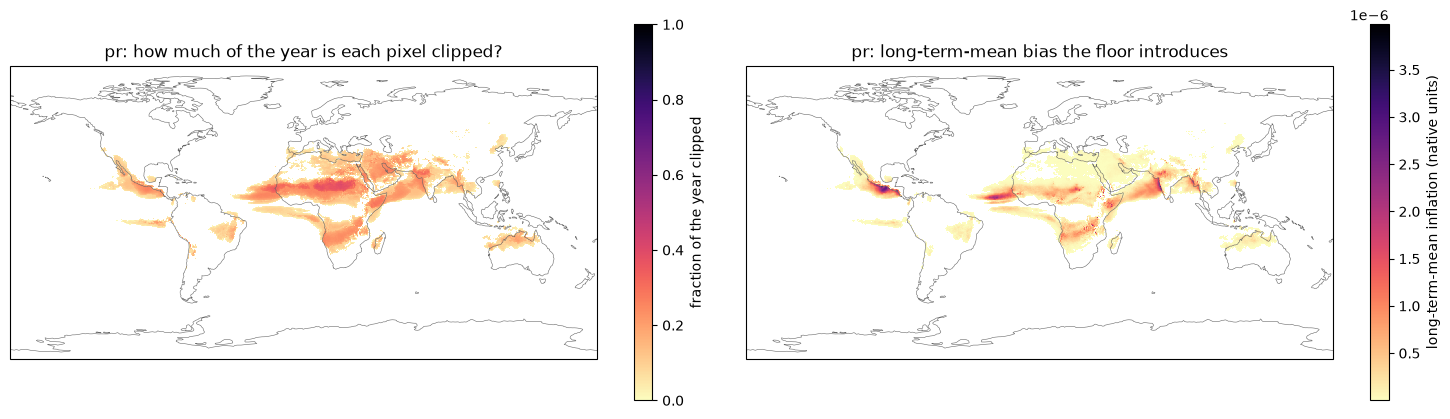

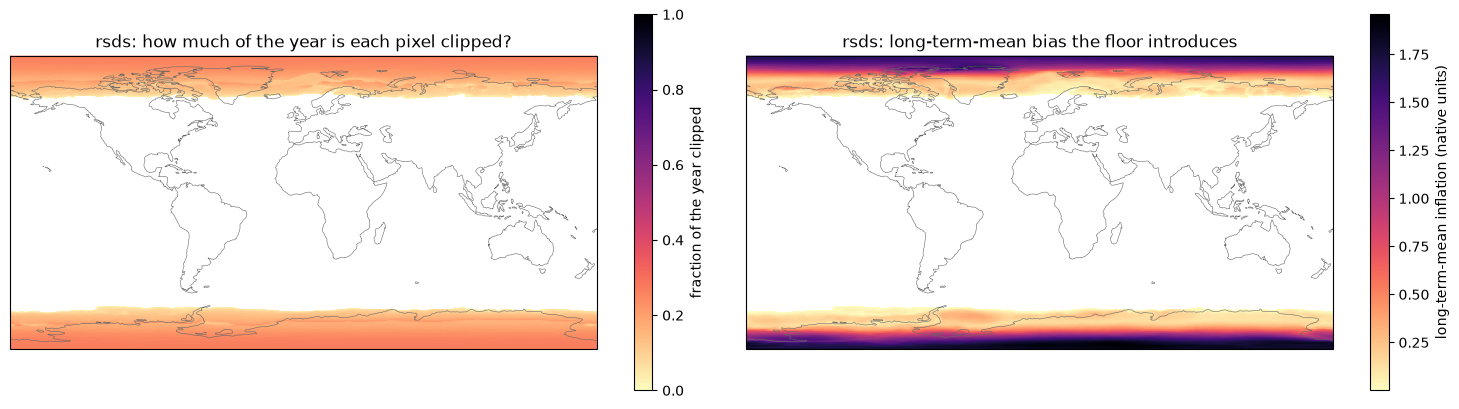

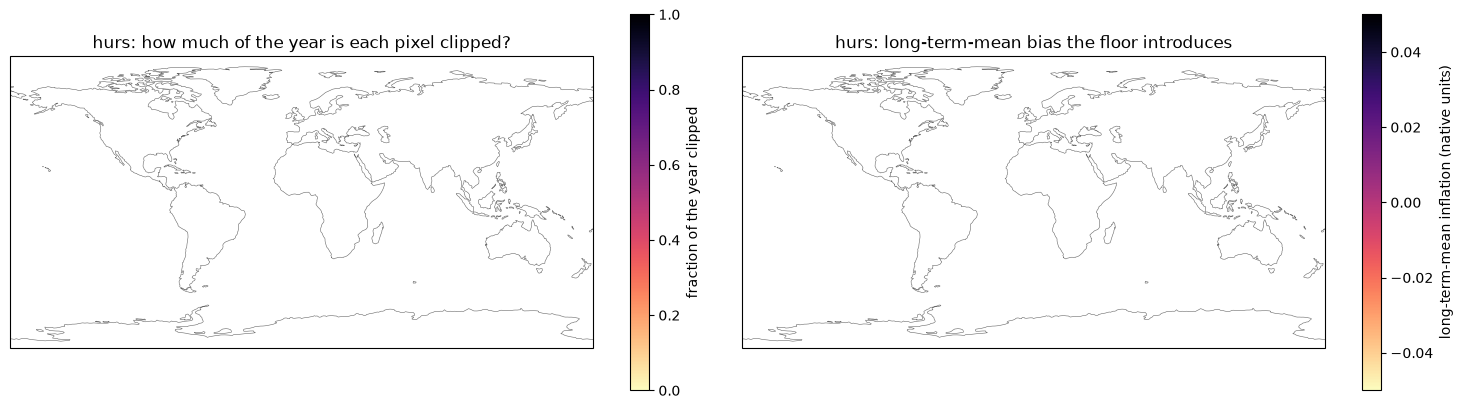

In [13]:
def plot_clip_maps(var: str, ds: xr.Dataset) -> None:
    frac_of_year = ds.would_be_clipped.mean("dayofyear")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={"projection": ccrs.PlateCarree()})

    frac_of_year.where(frac_of_year > 0).plot(
        ax=axes[0],
        transform=ccrs.PlateCarree(),
        vmin=0,
        vmax=1,
        cmap="magma_r",
        cbar_kwargs={"label": "fraction of the year clipped", "shrink": 0.8},
    )
    axes[0].set_title(f"{var}: how much of the year is each pixel clipped?")

    ds.mean_inflation.where(ds.mean_inflation > 0).plot(
        ax=axes[1],
        transform=ccrs.PlateCarree(),
        cmap="magma_r",
        cbar_kwargs={"label": "long-term-mean inflation (native units)", "shrink": 0.8},
    )
    axes[1].set_title(f"{var}: long-term-mean bias the floor introduces")

    for ax in axes:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
    plt.tight_layout()
    plt.show()


for var, ds in results.items():
    plot_clip_maps(var, ds)

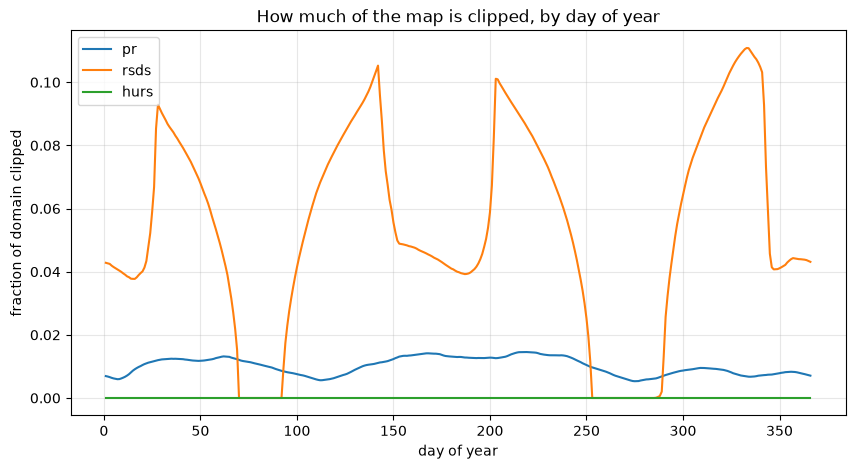

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for var, ds in results.items():
    frac_by_doy = ds.would_be_clipped.mean(["lat", "lon"])
    ax.plot(frac_by_doy["dayofyear"], frac_by_doy, label=var)
ax.set_xlabel("day of year")
ax.set_ylabel(
    "fraction of domain clipped"
)  # a fraction, not a physical quantity -- label it as one
ax.set_title("How much of the map is clipped, by day of year")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Summary

*This notebook has not been executed here -- it needs cluster + S3 access to ERA5. Fill in this
section with the actual numbers once it's been run.*

What to look for:

- **The summary table**: which variables have a non-trivial `frac_daycell_clipped`? The floor
  applies unconditionally to every downscaled variable, but the mechanism only triggers when the
  FFT fit actually swings negative, so expect this to concentrate in variables whose real seasonal
  cycle comes close to a hard physical floor of zero (`pr`, `rsds`, plausibly `hurs`) and to be at
  or near zero for the temperature variables (`tas`, `tasmax`, `tasmin`), whose values in Kelvin
  never come remotely close to zero.
- **The maps**: does `frac_of_year clipped` concentrate in specific climate zones -- e.g. bimodal or
  monsoonal precipitation regions, where a 3-harmonic fit struggles to represent two separate rainy
  seasons without ringing in the trough between them? Does that line up with the low-skill band
  already seen in `downscaling_bias_artifacts_explainer.ipynb`'s Part 2 R²/NSE maps?
- **`mean_inflation`**: is the long-term-mean bias small enough to ignore, or large relative to the
  variable's actual climatological mean? It's reported in native units in the table; also worth
  computing as a percent of `doy_mean_simple`'s mean at the same pixels, for scale.
- **The day-of-year comparison plot**: does clipping concentrate at particular times of year across
  variables (e.g. transition seasons), or is it spread evenly through the year?

In [11]:
cluster.shutdown()